# Notebook 5: Model Training
---
Trains the `HybridFashionModel` using imputed physical features and color harmony scores.

**Prerequisites:**
- NB03 completed (imputed manifests + encoder artifacts)
- NB04 completed (`color_harmony_scores.json`)

**Outputs:**
- `saved_models/best_hybrid_model.pth`
- `saved_models/thresholds.json`
- `saved_models/score_normalization.json`
- `saved_models/training_config.json`
- `saved_models/training_history.json`
- `saved_models/artifact_manifest.json`


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import warnings
warnings.filterwarnings('ignore')

from scripts.config import (
    DATA_RAW_DIR, DATA_PROCESSED_DIR, SAVED_MODELS_DIR,
    TRAIN_MANIFEST, VAL_MANIFEST,
    TRAIN_IMPUTED_MANIFEST, VAL_IMPUTED_MANIFEST,
)

print("Project root:", Path("..").resolve())
print("Processed dir:", DATA_PROCESSED_DIR)
print("Saved models dir:", SAVED_MODELS_DIR)

Project root: /Users/hazron/O4U
Processed dir: /Users/hazron/O4U/data/processed
Saved models dir: /Users/hazron/O4U/saved_models


## Step 2: Train the Model

Calls `scripts/train.py` which implements:
- Full reproducibility seeding
- Calibration split (20% of train, stratified) for threshold tuning
- Ensemble fold split (15% of remaining) for NB04–07
- Warmup + cosine annealing LR schedule
- Multi-task loss (MSE + BCE + consistency)
- Best model selection by ROC-AUC
- Youden's J threshold tuning on calibration split
- Per-group metric reporting
- Model card artifact saving

In [2]:
import subprocess, sys

cmd = [
    sys.executable, "-m", "scripts.train",
    "--seed", "42",
    "--save-metric", "roc_auc",
    "--feature-set", "full",
    "--epochs", "50",
    "--warmup-epochs", "3",
    "--lr", "1e-4",
    "--batch-size", "32",
    "--alpha", "0.5",
    "--consistency-weight", "0.1",
    "--patience", "10",   # stop if no improvement for 10 epochs; set to 0 to disable
]

print("Starting training...")
print("Command:", " ".join(cmd))
print("-" * 60)

result = subprocess.run(cmd, cwd=str(Path("..").resolve()))

if result.returncode == 0:
    print("\nTraining complete!")
else:
    print(f"\nTraining failed with exit code {result.returncode}")

Starting training...
Command: /opt/anaconda3/envs/fashion_env/bin/python -m scripts.train --seed 42 --save-metric roc_auc --feature-set full --epochs 50 --warmup-epochs 3 --lr 1e-4 --batch-size 32 --alpha 0.5 --consistency-weight 0.1 --patience 10
------------------------------------------------------------
O4U HybridFashionModel — Training
  seed=42  save_metric=roc_auc  feature_set=full
  epochs=50  warmup=3  lr=0.0001  batch=32
  alpha=0.5  consistency_weight=0.1
  Physical features: 99 cols
  Splits — deep_train: 6,854  calib: 2,016  ensemble_train: 1,210  val: 2,520
  Score normalization — mean=1.4027  std=0.8319
  Device: mps
  Color harmony scores loaded: 15,748 outfits (+4 dims)
 Checking/Caching 6854 visual features...
 Checking/Caching 2520 visual features...
 Checking/Caching 2016 visual features...
  Model params: 6,827,842
  Early stopping: patience=10 epochs (metric: roc_auc)

Starting training...



Epoch 001/50 | train_loss=0.6221 | val_loss=0.3530 | roc_auc=0.9219 | f1=0.9248 | inconsistency=0.659 | lr=5.56e-05 ← best


Epoch 002/50 | train_loss=0.3849 | val_loss=0.3115 | roc_auc=0.9383 | f1=0.9285 | inconsistency=0.471 | lr=7.78e-05 ← best


Epoch 003/50 | train_loss=0.3477 | val_loss=0.2857 | roc_auc=0.9425 | f1=0.9291 | inconsistency=0.534 | lr=1.00e-04 ← best


Epoch 004/50 | train_loss=0.3337 | val_loss=0.3343 | roc_auc=0.9315 | f1=0.9269 | inconsistency=0.657 | lr=9.99e-05


...

Epoch 011/50 | train_loss=0.2385 | val_loss=0.3347 | roc_auc=0.9432 | f1=0.9001 | inconsistency=0.603 | lr=9.30e-05


Epoch 012/50 | train_loss=0.2208 | val_loss=0.3560 | roc_auc=0.9374 | f1=0.9220 | inconsistency=0.392 | lr=9.12e-05


Epoch 013/50 | train_loss=0.2037 | val_loss=0.3524 | roc_auc=0.9416 | f1=0.8958 | inconsistency=0.450 | lr=8.92e-05


Epoch 014/50 | train_loss=0.1931 | val_loss=0.3977 | roc_auc=0.9433 | f1=0.8902 | inconsistency=0.486 | lr=8.71e-05


Epoch 015/50 | train_loss=0.1897 | val_loss=0.3637 | roc_auc=0.9414 | f1=0.8971 | inconsistency=0.538 | lr=8.48e-05

Early stopping triggered: no improvement in roc_auc for 10 consecutive epochs.

Training history saved to /Users/hazron/O4U/saved_models/training_history.json
Training complete. Best roc_auc: 0.9486

Tuning threshold on calibration split (Youden's J)...
  Optimal threshold: 0.3100  (Youden's J=0.7832)
  Calibration ROC-AUC: 0.9397

Computing per-group metrics on validation split...
  Body figure groups: []

Saving model card artifacts...
  Saved training_config.json
  Saved artifact_manifest.json

All artifacts saved:
  OK        best_hybrid_model.pth
  OK        score_normalization.json
  OK        thresholds.json
  OK        training_config.json
  OK        artifact_manifest.json

Done.

Training complete!


## Step 3: Verify Saved Artifacts

In [3]:
import json

expected_artifacts = [
    "best_hybrid_model.pth",
    "phys_feature_cols.json",
    "encoder_mapping.json",
    "thresholds.json",
    "score_normalization.json",
    "training_config.json",
    "artifact_manifest.json",
]

print("Artifact check:")
all_ok = True
for name in expected_artifacts:
    path = SAVED_MODELS_DIR / name
    status = "OK" if path.exists() else "MISSING"
    if status == "MISSING":
        all_ok = False
    print(f"  {status:8s}  {name}")

if all_ok:
    print("\nAll artifacts present.")
    
    # Show key training config
    with open(SAVED_MODELS_DIR / "training_config.json") as f:
        cfg = json.load(f)
    print("\nTraining config summary:")
    for k in ['seed', 'feature_set', 'save_metric', 'timestamp']:
        if k in cfg:
            print(f"  {k}: {cfg[k]}")
    if 'training' in cfg:
        print(f"  epochs: {cfg['training'].get('epochs')}")
        print(f"  lr: {cfg['training'].get('lr')}")
    
    # Show threshold
    with open(SAVED_MODELS_DIR / "thresholds.json") as f:
        thr = json.load(f)
    print(f"\nClassification threshold (Youden's J): {thr.get('classification_threshold', 'N/A'):.4f}")
else:
    print("\nSome artifacts are missing — check training output above.")

Artifact check:
  OK        best_hybrid_model.pth
  OK        phys_feature_cols.json
  OK        encoder_mapping.json
  OK        thresholds.json
  OK        score_normalization.json
  OK        training_config.json
  OK        artifact_manifest.json

All artifacts present.

Training config summary:
  seed: 42
  feature_set: full
  save_metric: roc_auc
  timestamp: 2026-05-12T07:33:07.015066Z
  epochs: 50
  lr: 0.0001

Classification threshold (Youden's J): 0.3100


## Step 4: Training Curves

Plots train/val loss, validation ROC-AUC, F1, and learning rate across epochs.
The best epoch (highest ROC-AUC) is marked with a dashed vertical line.

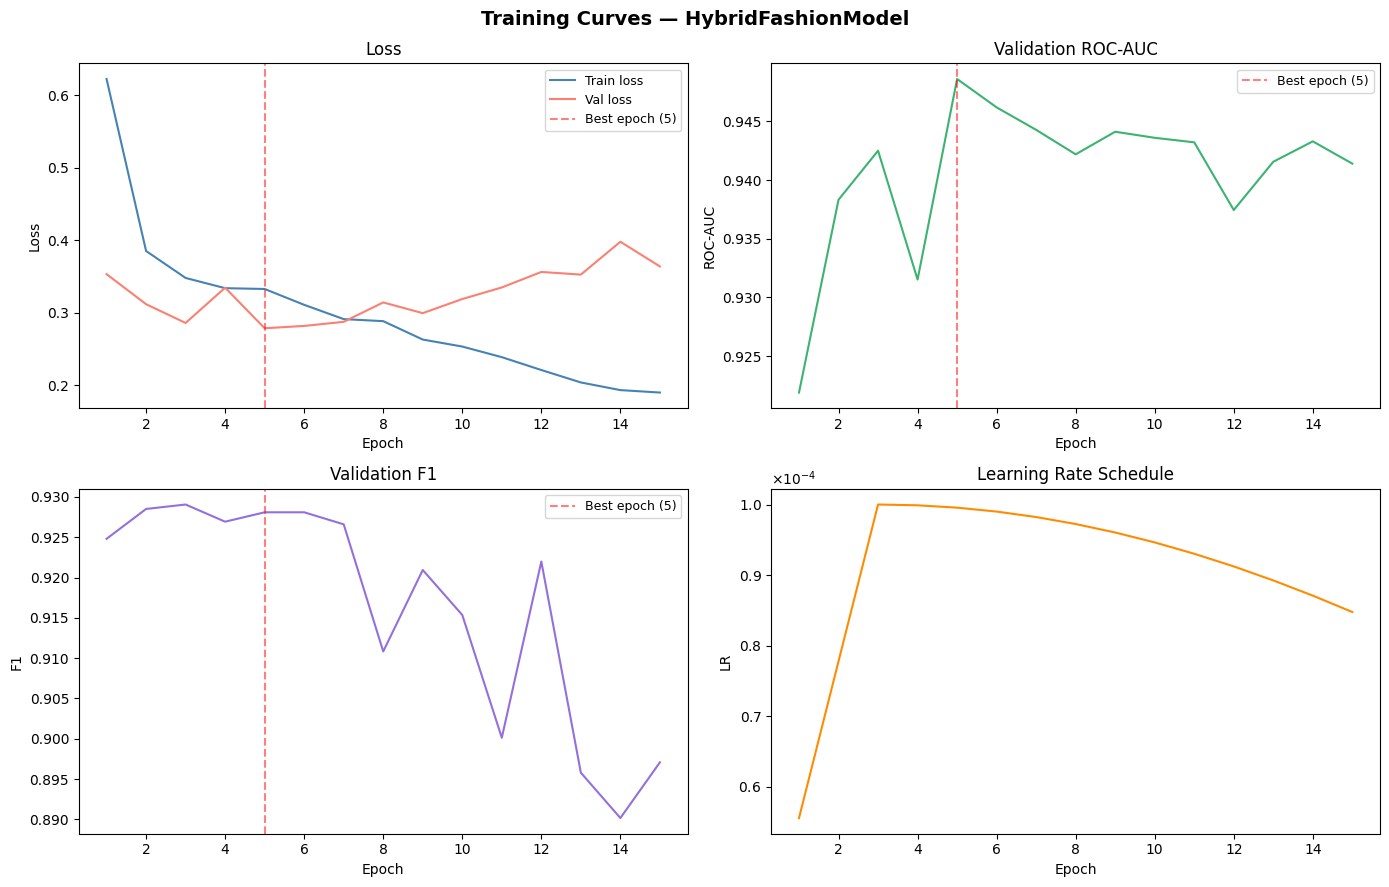

Best epoch: 5  |  Best ROC-AUC: 0.9486  |  F1 at best: 0.9281
Plot saved to plots/training_curves.png


In [4]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

history_path = SAVED_MODELS_DIR / "training_history.json"

if not history_path.exists():
    print("training_history.json not found — re-run training to generate it.")
else:
    with open(history_path) as f:
        history = json.load(f)

    epochs      = [h["epoch"]       for h in history]
    train_loss  = [h["train_loss"]  for h in history]
    val_loss    = [h["val_loss"]    for h in history]
    roc_auc     = [h["roc_auc"]     for h in history]
    f1          = [h["f1"]          for h in history]
    lr          = [h["lr"]          for h in history]

    # Best epoch by ROC-AUC
    best_epoch = epochs[roc_auc.index(max(roc_auc))]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("Training Curves — HybridFashionModel", fontsize=14, fontweight="bold")

    def mark_best(ax):
        ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({best_epoch})")
        ax.legend(fontsize=9)

    # --- Train vs Val Loss ---
    ax = axes[0, 0]
    ax.plot(epochs, train_loss, label="Train loss", color="steelblue")
    ax.plot(epochs, val_loss,   label="Val loss",   color="salmon")
    ax.set_title("Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    mark_best(ax)

    # --- Validation ROC-AUC ---
    ax = axes[0, 1]
    ax.plot(epochs, roc_auc, color="mediumseagreen")
    ax.set_title("Validation ROC-AUC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("ROC-AUC")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
    mark_best(ax)

    # --- Validation F1 ---
    ax = axes[1, 0]
    ax.plot(epochs, f1, color="mediumpurple")
    ax.set_title("Validation F1")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
    mark_best(ax)

    # --- Learning Rate ---
    ax = axes[1, 1]
    ax.plot(epochs, lr, color="darkorange")
    ax.set_title("Learning Rate Schedule")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("LR")
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

    plt.tight_layout()
    plt.savefig(str(SAVED_MODELS_DIR.parent / "plots" / "training_curves.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Best epoch: {best_epoch}  |  Best ROC-AUC: {max(roc_auc):.4f}  |  F1 at best: {f1[roc_auc.index(max(roc_auc))]:.4f}")
    print("Plot saved to plots/training_curves.png")

## Summary

| Step | Output |
|---|---|
| Imputation pipeline | `train_imputed_manifest.json`, `val_imputed_manifest.json`, `encoder_mapping.json`, `phys_feature_cols.json` |
| Model training | `best_hybrid_model.pth`, `thresholds.json`, `score_normalization.json`, `training_history.json` |
| Model card | `training_config.json`, `artifact_manifest.json` |
| Training curves | `plots/training_curves.png` |

**Next step:** Run NB04 to evaluate the model on the test set and run inference demos.